# Bài 2 — Phân lớp US Accidents

Dự đoán mức độ nghiêm trọng `Severity` (1–4) từ điều kiện thời tiết, thời gian và hạ tầng giao thông.

## Mục tiêu và phương pháp

- Dữ liệu mất cân bằng mạnh nên dùng **F1-macro** làm chỉ số chính, kèm precision/recall/F1 theo từng lớp và ma trận nhầm lẫn.
- So sánh baseline dự đoán lớp đa số, Logistic Regression và Decision Tree.
- Dùng `class_weight='balanced'` để tăng trọng số cho Severity 1 và 4.
- Tách train/validation/test theo stratify; validation chỉ dùng để chọn `max_depth`, test chỉ dùng cho đánh giá cuối.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TARGET = 'Severity'
DATA_PATH = Path('../data/processed/us_accidents/us_accidents_classification.csv')
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Missing values:', int(df.isna().sum().sum()))
display(df.head())
display(df.dtypes.to_frame('dtype'))

Shape: (80000, 23)
Missing values: 0


,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Distance(mi),Hour_of_Day,Is_Weekend,Amenity,...,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Infra_Feature_Count,Severity
0,99.0,35.0,29.95,10.0,10.4,0.00,0.000,15.0,False,False,...,False,False,False,False,False,False,False,True,2,2
1,46.0,93.0,30.00,6.0,6.0,0.00,0.000,20.0,False,False,...,False,False,False,False,False,False,False,False,0,2
2,67.0,66.0,29.84,10.0,9.0,0.00,0.000,5.0,True,False,...,True,False,False,False,False,False,False,False,1,2
3,50.0,89.0,29.18,3.0,3.0,0.01,0.831,13.0,False,False,...,False,False,False,False,False,False,False,False,0,2
4,77.0,94.0,29.49,6.0,5.0,0.03,0.000,14.0,False,False,...,False,False,False,False,False,False,False,False,0,3


,dtype
Temperature(F),float64
Humidity(%),float64
Pressure(in),float64
Visibility(mi),float64
Wind_Speed(mph),float64
Precipitation(in),float64
Distance(mi),float64
Hour_of_Day,float64
Is_Weekend,bool
Amenity,bool


          count  percent
Severity                
1           520     0.65
2         65334    81.67
3         13439    16.80
4           707     0.88


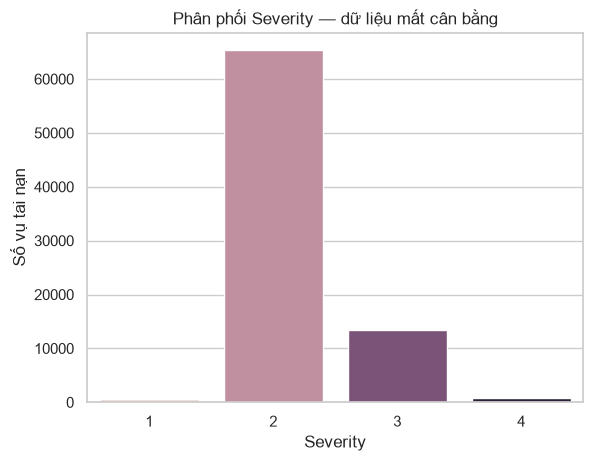

Nhận xét: lớp 2 chiếm đa số; accuracy đơn thuần không phản ánh chất lượng trên lớp hiếm 1 và 4.


In [3]:
severity_counts = df[TARGET].value_counts().sort_index()
severity_pct = (severity_counts / len(df) * 100).round(2)
print(pd.DataFrame({'count': severity_counts, 'percent': severity_pct}))

ax = sns.countplot(data=df, x=TARGET, order=sorted(df[TARGET].unique()), hue=TARGET, legend=False)
ax.set(title='Phân phối Severity — dữ liệu mất cân bằng', ylabel='Số vụ tai nạn')
plt.show()

print('Nhận xét: lớp 2 chiếm đa số; accuracy đơn thuần không phản ánh chất lượng trên lớp hiếm 1 và 4.')

In [4]:
X = df.drop(columns=TARGET)
y = df[TARGET]

# Test 20%; phần còn lại tách validation 20% để chọn siêu tham số.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, stratify=y_train_val, random_state=RANDOM_STATE
)

for name, labels in {'train': y_train, 'validation': y_val, 'test': y_test}.items():
    print(f'\n{name}: {len(labels):,} dòng')
    print((labels.value_counts(normalize=True).sort_index() * 100).round(2))


train: 51,200 dòng
Severity
1     0.65
2    81.67
3    16.80
4     0.88
Name: proportion, dtype: float64

validation: 12,800 dòng
Severity
1     0.65
2    81.67
3    16.80
4     0.88
Name: proportion, dtype: float64

test: 16,000 dòng
Severity
1     0.65
2    81.67
3    16.80
4     0.88
Name: proportion, dtype: float64


In [5]:
# Baseline: mô hình luôn dự đoán lớp xuất hiện nhiều nhất.
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)
print('Dummy accuracy:', round(accuracy_score(y_val, dummy_pred), 4))
print('Dummy F1-macro:', round(f1_score(y_val, dummy_pred, average='macro', zero_division=0), 4))

Dummy accuracy: 0.8167
Dummy F1-macro: 0.2248


In [6]:
# Logistic Regression giả định log-odds tuyến tính theo đặc trưng; cần scale các biến liên tục.
logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced', max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE
    ))
])
logistic.fit(X_train, y_train)
logistic_val_pred = logistic.predict(X_val)
print('Logistic validation F1-macro:', round(f1_score(y_val, logistic_val_pred, average='macro', zero_division=0), 4))
print('Logistic validation balanced accuracy:', round(balanced_accuracy_score(y_val, logistic_val_pred), 4))

Logistic validation F1-macro: 0.2069
Logistic validation balanced accuracy: 0.4622


In [7]:
# Decision Tree không cần scale. Giới hạn độ sâu để giảm overfitting;
# min_samples_leaf=20 giúp lá chứa đủ quan sát của lớp hiếm.
depths = [4, 6, 8, 10, 12]
tuning_rows = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    tuning_rows.append({
        'max_depth': depth,
        'f1_macro_validation': f1_score(y_val, pred, average='macro', zero_division=0),
        'balanced_accuracy_validation': balanced_accuracy_score(y_val, pred)
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values('f1_macro_validation', ascending=False)
display(tuning_results)
best_depth = int(tuning_results.iloc[0]['max_depth'])
print('Chọn max_depth =', best_depth, 'theo F1-macro validation cao nhất.')

,max_depth,f1_macro_validation,balanced_accuracy_validation
4,12,0.275968,0.494308
3,10,0.266312,0.517368
2,8,0.262318,0.540840
1,6,0.201643,0.554568
0,4,0.159143,0.544597


Chọn max_depth = 12 theo F1-macro validation cao nhất.


In [8]:
# Huấn luyện lại trên train + validation, sau đó đánh giá đúng một lần trên test.
final_models = {
    'Dummy (lớp đa số)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression (balanced)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced', max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE
        ))
    ]),
    f'Decision Tree (depth={best_depth}, balanced)': DecisionTreeClassifier(
        max_depth=best_depth, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE
    )
}

test_summary = []
predictions = {}
for name, model in final_models.items():
    model.fit(X_train_val, y_train_val)
    pred = model.predict(X_test)
    predictions[name] = pred
    test_summary.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, pred),
        'f1_macro': f1_score(y_test, pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_test, pred, average='weighted', zero_division=0)
    })

test_summary = pd.DataFrame(test_summary).sort_values('f1_macro', ascending=False)
display(test_summary.style.format({
    'accuracy': '{:.4f}', 'balanced_accuracy': '{:.4f}', 'f1_macro': '{:.4f}', 'f1_weighted': '{:.4f}'
}))

,model,accuracy,balanced_accuracy,f1_macro,f1_weighted
2,"Decision Tree (depth=12, balanced)",0.4843,0.5297,0.2881,0.5737
0,Dummy (lớp đa số),0.8167,0.2500,0.2248,0.7343
1,Logistic Regression (balanced),0.3222,0.4629,0.2127,0.4016



Dummy (lớp đa số)
              precision    recall  f1-score   support

           1     0.0000    0.0000    0.0000       104
           2     0.8167    1.0000    0.8991     13067
           3     0.0000    0.0000    0.0000      2688
           4     0.0000    0.0000    0.0000       141

    accuracy                         0.8167     16000
   macro avg     0.2042    0.2500    0.2248     16000
weighted avg     0.6670    0.8167    0.7343     16000



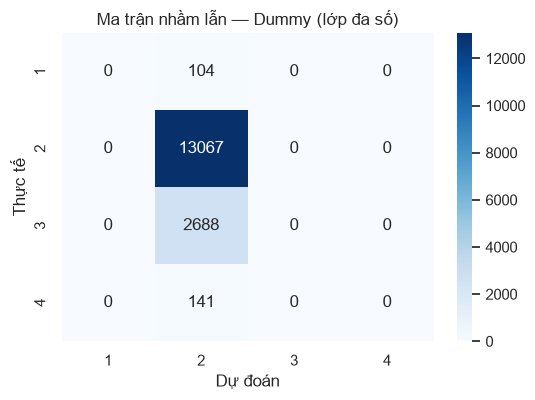


Logistic Regression (balanced)
              precision    recall  f1-score   support

           1     0.0169    0.6442    0.0330       104
           2     0.9344    0.2680    0.4165     13067
           3     0.2652    0.5707    0.3621      2688
           4     0.0207    0.3688    0.0393       141

    accuracy                         0.3222     16000
   macro avg     0.3093    0.4629    0.2127     16000
weighted avg     0.8079    0.3222    0.4016     16000



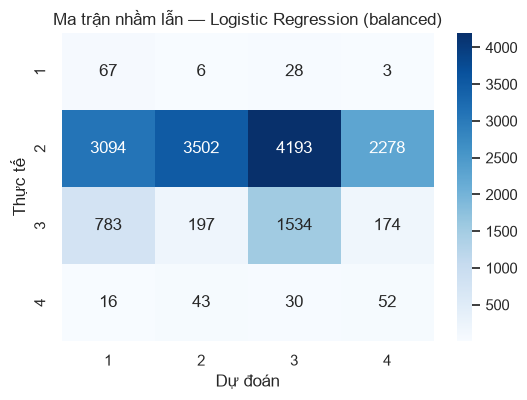


Decision Tree (depth=12, balanced)
              precision    recall  f1-score   support

           1     0.0283    0.5385    0.0537       104
           2     0.9383    0.4537    0.6116     13067
           3     0.3341    0.6302    0.4367      2688
           4     0.0266    0.4965    0.0505       141

    accuracy                         0.4843     16000
   macro avg     0.3318    0.5297    0.2881     16000
weighted avg     0.8228    0.4843    0.5737     16000



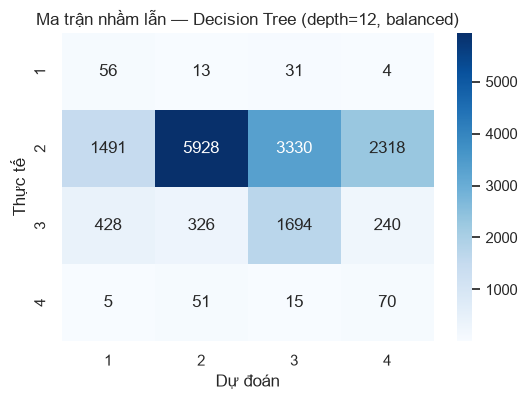

In [9]:
labels = sorted(y.unique())
for name, pred in predictions.items():
    print('\n' + '=' * 80)
    print(name)
    print('=' * 80)
    print(classification_report(y_test, pred, labels=labels, digits=4, zero_division=0))

    cm = confusion_matrix(y_test, pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Ma trận nhầm lẫn — {name}')
    plt.xlabel('Dự đoán')
    plt.ylabel('Thực tế')
    plt.show()

## Khung nhận xét cho báo cáo

1. So sánh Dummy với hai mô hình: nếu Dummy có accuracy cao nhưng F1-macro thấp, điều đó xác nhận accuracy đơn thuần gây hiểu lầm.
2. Chọn mô hình theo F1-macro và báo cáo precision/recall/F1 của từng Severity, đặc biệt là 1 và 4.
3. Decision Tree mô hình hóa được tương tác phi tuyến giữa thời tiết, thời gian và hạ tầng; Logistic Regression là baseline tuyến tính, dễ diễn giải nhưng có thể không nắm bắt quan hệ phức tạp.
4. `class_weight='balanced'` cải thiện sự chú ý tới lớp hiếm nhưng có thể giảm accuracy và tăng false positive ở lớp 1/4. Nêu rõ đánh đổi này dựa trên ma trận nhầm lẫn.